 
## Industrial Chemical Reactor Yield Prediction Using Machine Learning 
### Project Overview 

--- 

Modern chemical manufacturing relies on computationally intensive reactor simulations based 
on reaction kinetics, heat transfer, and fluid dynamics. Although these simulations provide 
accurate predictions, they are often too slow for real-time industrial optimization. 
This project develops a **machine learning surrogate model** capable of predicting the 
**Overall Yield of Product B** directly from reactor operating conditions. The objective is to 
replace expensive physics-based simulations with a fast and accurate predictive model that can 
support process optimization and operational decision-making. --- 
## Reaction Network 
### Desired Reaction 
A → B 
### Side Reaction 
B → C 
The machine learning model learns the complex nonlinear relationship between reactor 
operating conditions and the final yield of Product B. --- 
## Objectives - Understand the reactor operating dataset - Perform exploratory data analysis - Engineer meaningful process features - Train multiple regression models - Compare model performance using RMSE - Build an ensemble prediction model - Generate predictions for unseen operating conditions - Export the final submission file

#  Import Required Libraries 
The following libraries are used throughout this notebook. 
### Data Manipulation
*   **Pandas 
*   **NumPy 
### Data Visualization
*   **Matplotlib 
*   **Seaborn 
### Machine Learning 
*   **Scikit-Learn 
*   **XGBoost 
*   **CatBoost 
 
### Model Explainability 
*   **SHAP 
### Hyperparameter Optimization 
*   **RandomizedSearchCV 
*   **GridSearchCV 

In [1]:
# Data Manipulation 
import pandas as pd 
import numpy as np 

# Visualization 
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.style.use("ggplot") 

# Ignore Warnings 
import warnings 
warnings.filterwarnings("ignore") 

# Machine Learning 
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import KFold 
from sklearn.model_selection import cross_val_score 
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV 
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import r2_score 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.ensemble import GradientBoostingRegressor 
from sklearn.ensemble import ExtraTreesRegressor

# Advanced Models 
from xgboost import XGBRegressor 
from catboost import CatBoostRegressor 
 

# Explainability 
import shap 
print("All Libraries Imported Successfully.")

All Libraries Imported Successfully.


#  Load Training and Testing Dataset 
The training dataset contains historical operating conditions together with the target variable 
(**overall_yield**). 
The testing dataset contains only reactor operating conditions. Our trained machine learning 
model will generate predictions for these unseen observations. 

In [2]:
train = pd.read_csv("train_dataset.csv") 
test = pd.read_csv("test_dataset.csv") 
print("="*50) 
print("Training Dataset Shape :", train.shape) 
print("Testing Dataset Shape  :", test.shape) 
print("="*50) 
train.head()

Training Dataset Shape : (150, 6)
Testing Dataset Shape  : (50, 5)


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211


#  Dataset Overview 
Before developing machine learning models, it is important to understand the structure and 
quality of the dataset. 
This section provides: 
*   Number of observations 
*   Number of features 
*   Data types 
*   Memory usage 
*   Basic overview of the dataset
    

In [3]:
print("="*60) 
print("Training Dataset Information") 
print("="*60) 
train.info()

Training Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   flow_rate_L_min       150 non-null    float64
 1   concentration_mol_L   150 non-null    float64
 2   inlet_temperature_K   150 non-null    float64
 3   length_m              150 non-null    float64
 4   jacket_temperature_K  150 non-null    float64
 5   overall_yield         150 non-null    float64
dtypes: float64(6)
memory usage: 7.2 KB


# Display Sample Records 
Visual inspection of the first few rows helps verify that the dataset has been loaded correctly and 
provides an understanding of the feature values. 

In [4]:
display(train.head()) 

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211


In [5]:
display(train.tail())

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
145,7.77,2.33,492.09,12.90,529.91,0.000
146,50.72,3.19,497.90,17.35,426.78,1.249
147,42.70,1.26,463.01,5.96,458.71,0.645
148,8.86,2.68,406.44,6.42,531.29,0.000
149,25.90,0.80,362.53,2.94,474.85,28.516


#  Statistical Summary 
Statistical analysis provides useful insights into the numerical distribution of each feature, 
including: 
* Mean 
* Standard Deviation 
* Minimum 
* Maximum 
* Quartiles 

In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
flow_rate_L_min,150.0,40.466800,22.239772,5.41,21.1125,38.610,61.2275,79.020
concentration_mol_L,150.0,2.311333,1.019844,0.52,1.3625,2.445,3.1550,3.970
inlet_temperature_K,150.0,424.423400,45.200641,351.63,387.2550,425.630,462.9725,498.580
length_m,150.0,14.086533,6.995343,2.26,8.0275,14.235,20.6850,24.990
jacket_temperature_K,150.0,442.240800,55.047768,354.01,393.3275,437.080,486.1800,547.990
overall_yield,150.0,36.222173,38.427427,0.00,0.0135,15.314,74.8765,99.971


#  Missing Value Analysis 
Missing values can negatively affect machine learning performance. 
This section checks whether any missing observations exist within the dataset.

In [7]:
missing = train.isnull().sum() 
missing 

flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
overall_yield           0
dtype: int64

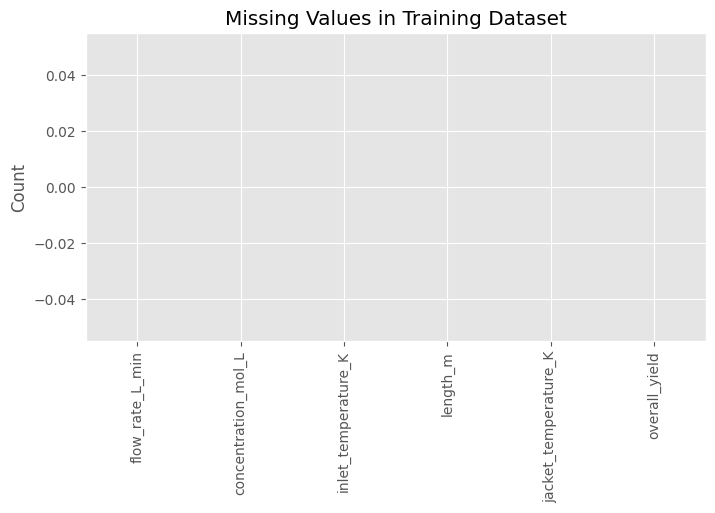

In [8]:
plt.figure(figsize=(8,4)) 
missing.plot( 
kind="bar", 
color="BLUE" 
) 
plt.title("Missing Values in Training Dataset") 
plt.ylabel("Count") 
plt.show()

# Duplicate Record Analysis 
Duplicate records may introduce bias during model training. 
This section identifies whether duplicate observations are present within the training dataset. 

In [9]:
duplicates = train.duplicated().sum() 
print("Duplicate Rows :", duplicates) 

Duplicate Rows : 0


#  Target Variable Analysis 
Understanding the distribution of the target variable is essential for selecting an appropriate 
regression model. 
The following visualization illustrates the distribution of the overall reactor yield.

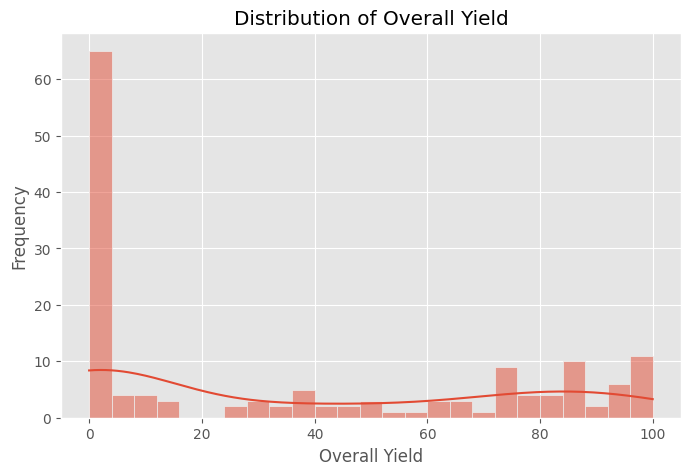

In [10]:
plt.figure(figsize=(8,5)) 
sns.histplot( 
train["overall_yield"], 
bins=25, 
kde=True 
) 
plt.title("Distribution of Overall Yield") 
plt.xlabel("Overall Yield") 
plt.ylabel("Frequency") 
plt.show() 

#  Correlation Analysis 
Correlation analysis helps identify relationships between reactor operating parameters and the 
target variable. 
Highly correlated variables may significantly influence reactor yield prediction.

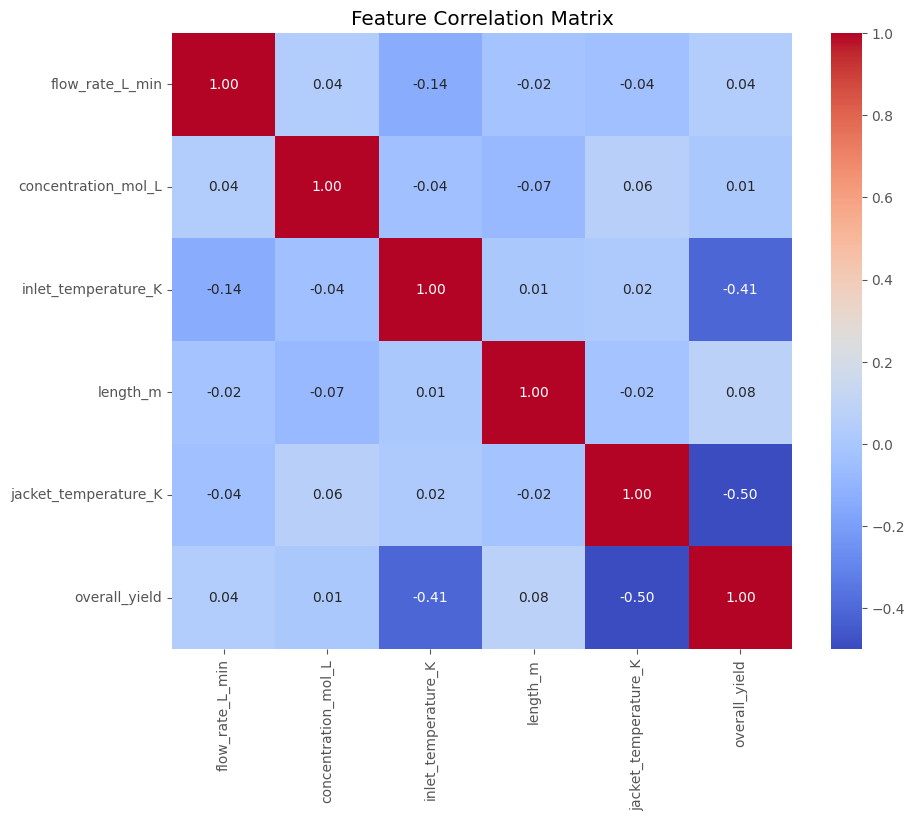

In [11]:
plt.figure(figsize=(10,8)) 
corr = train.corr() 
sns.heatmap( 
corr, 
annot=True, 
cmap="coolwarm", 
fmt=".2f" 
) 
plt.title("Feature Correlation Matrix") 
plt.show()

#  Pairwise Relationship Analysis 
Pairwise visualization helps understand the relationships among process variables and the 
target variable. 
Although the dataset is relatively small, pair plots provide valuable insight into trends, nonlinear 
relationships, and potential clustering patterns.

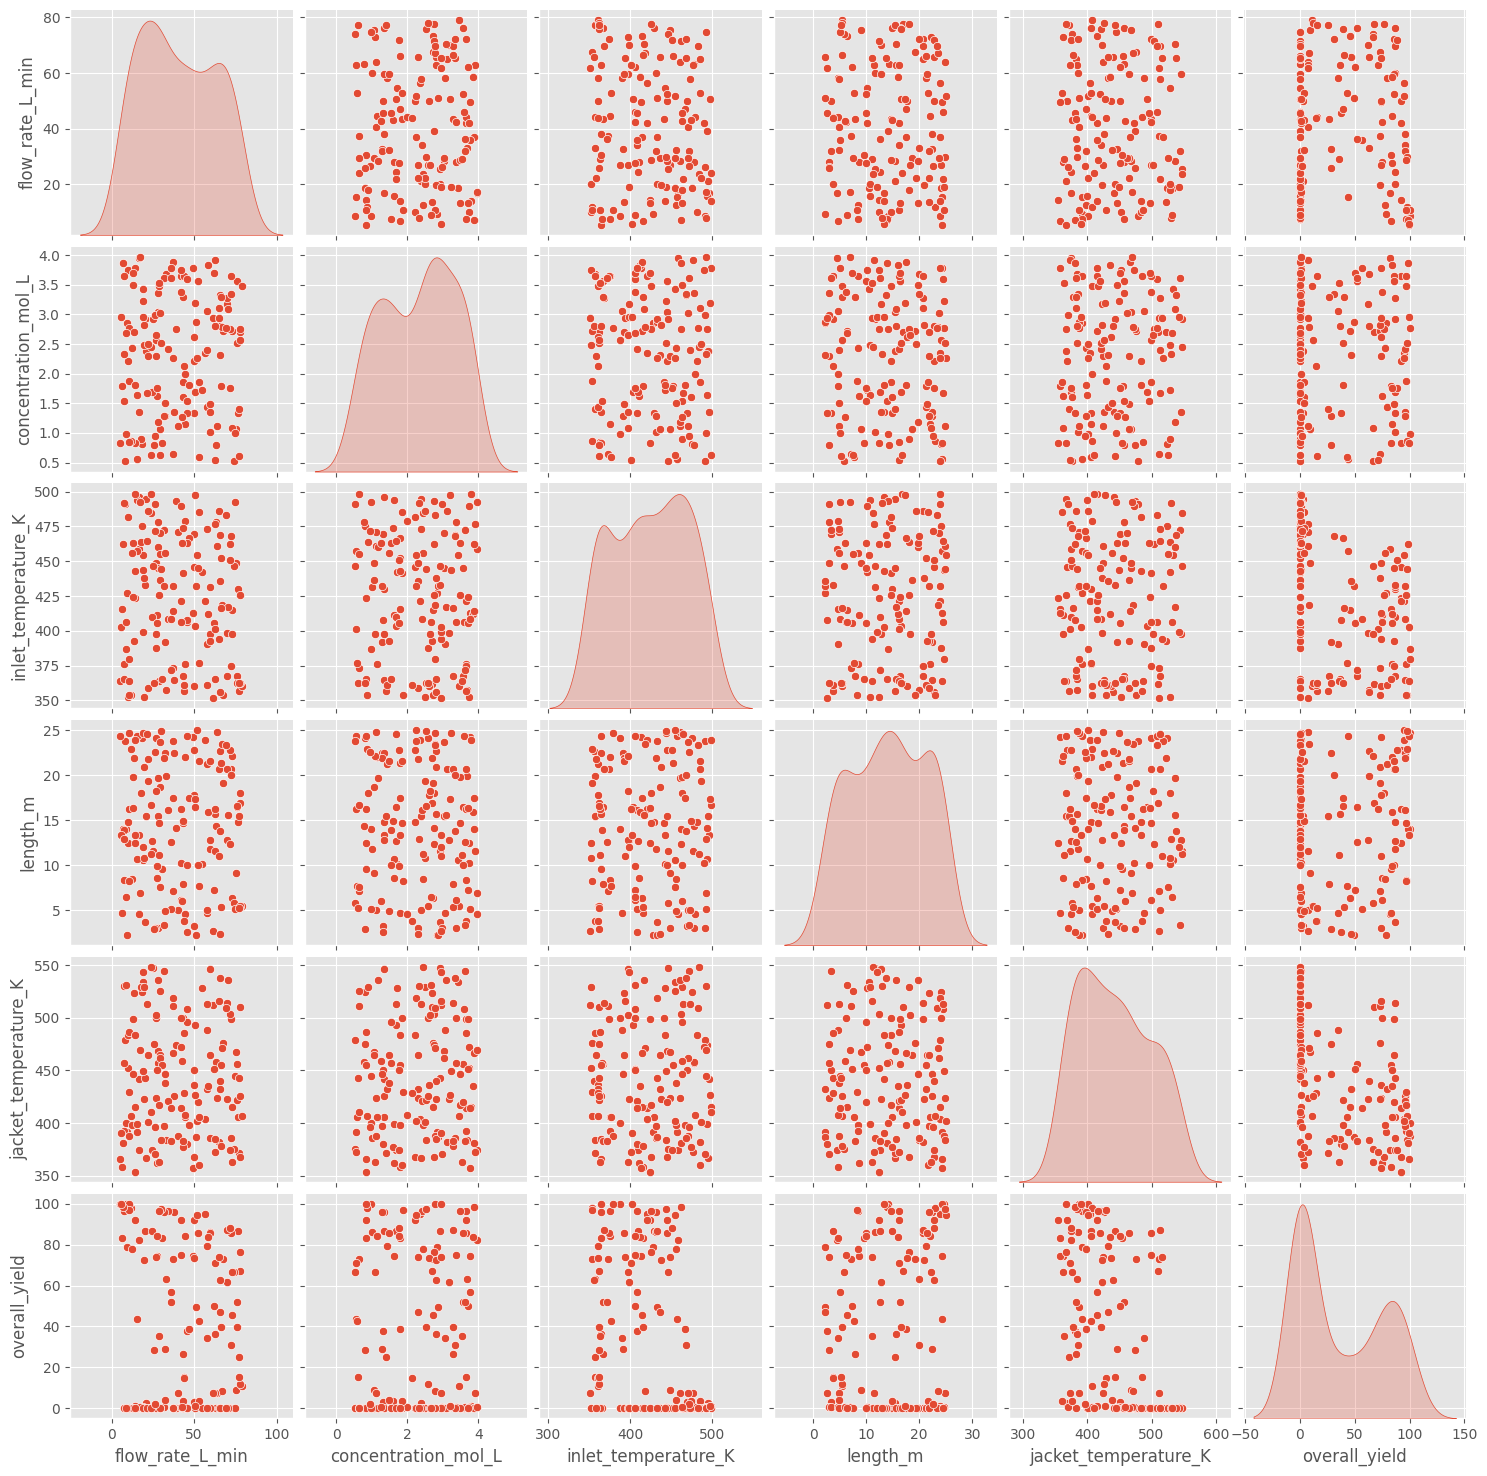

In [12]:
sns.pairplot( 
    train, 
    diag_kind="kde" 
) 
 
plt.show() 

#  Outlier Detection 
 
Boxplots provide a visual representation of feature distributions and help identify potential 
outliers that may influence model performance. 
 
Tree-based models are generally robust to outliers; however, understanding their presence 
remains an important step in exploratory analysis.

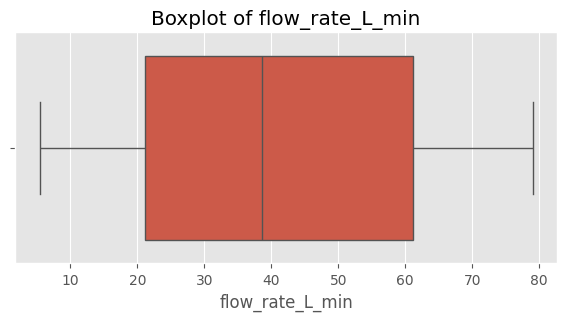

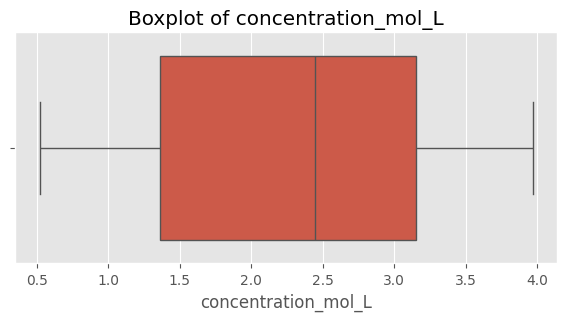

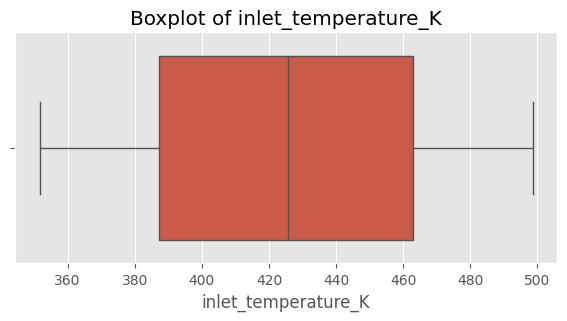

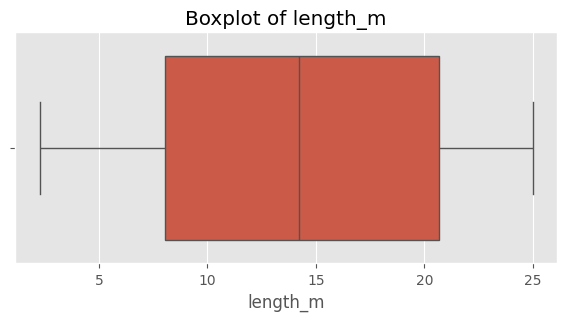

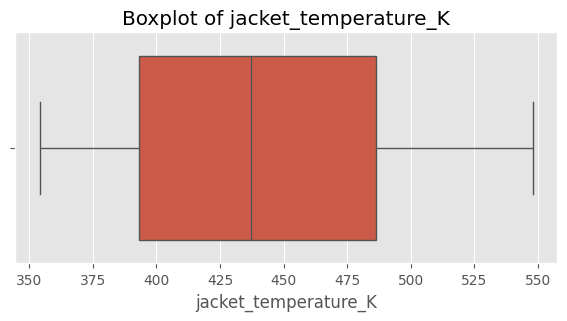

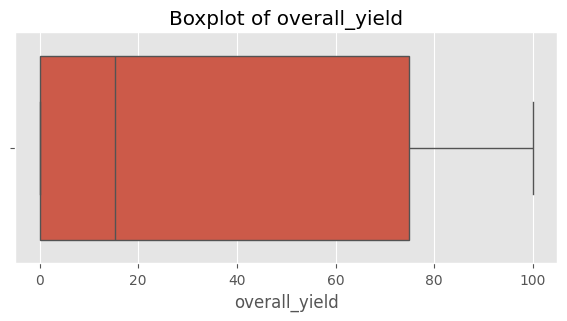

In [13]:
numerical_columns = [ 
    "flow_rate_L_min", 
    "concentration_mol_L", 
    "inlet_temperature_K", 
    "length_m", 
    "jacket_temperature_K", 
    "overall_yield" 
] 
 
for column in numerical_columns: 
 
    plt.figure(figsize=(7,3)) 
 
    sns.boxplot( 
        x=train[column] 
    ) 
 
    plt.title(f"Boxplot of {column}") 
 
    plt.show()

#  Feature Engineering 
 
Machine learning models often benefit from meaningful engineered features derived from 
domain knowledge. 
 
Since reactor yield depends on temperature gradients, residence time, and concentration-flow 
interactions, several additional variables are created.

In [14]:
# Temperature Difference 
 
train["temperature_difference"] = ( 
    train["jacket_temperature_K"] - 
    train["inlet_temperature_K"] 
) 
 
test["temperature_difference"] = ( 
    test["jacket_temperature_K"] - 
    test["inlet_temperature_K"] 
)

In [15]:
# Approximate Residence Time 
 
train["residence_time_index"] = ( 
    train["length_m"] / 
    train["flow_rate_L_min"] 
) 
 
test["residence_time_index"] = ( 
    test["length_m"] / 
    test["flow_rate_L_min"] 
) 

In [16]:
# Concentration × Flow Interaction 
 
train["flow_concentration"] = ( 
    train["flow_rate_L_min"] * 
    train["concentration_mol_L"] 
) 
 
test["flow_concentration"] = ( 
    test["flow_rate_L_min"] * 
    test["concentration_mol_L"] 
)

In [17]:
# Temperature Interaction 
 
train["thermal_energy_index"] = ( 
    train["inlet_temperature_K"] * 
    train["jacket_temperature_K"] 
) 
 
test["thermal_energy_index"] = ( 
    test["inlet_temperature_K"] * 
    test["jacket_temperature_K"] 
) 

In [18]:
train.head() 

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield,temperature_difference,residence_time_index,flow_concentration,thermal_energy_index
0,33.09,3.68,357.75,19.87,383.79,63.024,26.04,0.600484,121.7712,137300.8725
1,76.30,1.34,429.70,14.84,405.72,86.611,-23.98,0.194495,102.2420,174337.8840
2,59.90,1.01,431.10,11.76,385.40,86.347,-45.70,0.196327,60.4990,166145.9400
3,49.90,2.21,445.61,22.85,367.74,92.175,-77.87,0.457916,110.2790,163868.6214
4,16.70,3.95,458.91,4.56,374.13,82.211,-84.78,0.273054,65.9650,171691.9983


#  Feature and Target Separation 
 
The predictor variables are separated from the target variable before training regression 
models.

In [19]:
X = train.drop( 
    columns="overall_yield" 
) 
 
y = train["overall_yield"] 
 
print("Feature Matrix Shape :", X.shape) 
 
print("Target Shape :", y.shape)

Feature Matrix Shape : (150, 9)
Target Shape : (150,)


#  Train-Validation Split 
 
The dataset is divided into training and validation subsets. 
 
This allows objective evaluation of model performance before generating predictions for the 
unseen test dataset. 

In [20]:
X_train, X_valid, y_train, y_valid = train_test_split( 
 
    X, 
    y, 
 
    test_size=0.20, 
 
    random_state=42 
)

print("Training Samples :", X_train.shape) 
print("Validation Samples :", X_valid.shape)

Training Samples : (120, 9)
Validation Samples : (30, 9)


#  Machine Learning Model Development 
Several state-of-the-art regression algorithms are evaluated to identify the model that best 
captures the nonlinear relationships within the reactor process. 
The following models will be trained and compared: - Random Forest Regressor - Gradient Boosting Regressor - XGBoost Regressor - CatBoost Regressor - LightGBM Regressor 
The model with the lowest RMSE and highest R² Score will be selected for final prediction

#  Random Forest Regression 
Random Forest is an ensemble learning algorithm that combines multiple decision trees to 
improve prediction accuracy and reduce overfitting. 
It performs exceptionally well on nonlinear regression problems with relatively small datasets.

In [21]:
rf = RandomForestRegressor( 
n_estimators=500, 
max_depth=12, 
random_state=42 
) 
rf.fit(X_train, y_train) 
rf_pred = rf.predict(X_valid) 
rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_pred)) 
rf_r2 = r2_score(y_valid, rf_pred) 
print("Random Forest RMSE :", round(rf_rmse,4)) 
print("Random Forest R²   :", round(rf_r2,4)) 

Random Forest RMSE : 16.8892
Random Forest R²   : 0.8378


#  Gradient Boosting Regression 
Gradient Boosting builds trees sequentially, where each new tree learns from the errors of 
previous trees. 
This often improves predictive performance compared to a single ensemble model.

In [22]:
gbr = GradientBoostingRegressor( 
random_state=42 
) 
gbr.fit(X_train, y_train) 
gbr_pred = gbr.predict(X_valid) 
gbr_rmse = np.sqrt(mean_squared_error(y_valid, gbr_pred)) 
gbr_r2 = r2_score(y_valid, gbr_pred) 
print("Gradient Boosting RMSE :", round(gbr_rmse,4)) 
print("Gradient Boosting R²   :", round(gbr_r2,4))

Gradient Boosting RMSE : 13.6872
Gradient Boosting R²   : 0.8935


#  XGBoost Regression 
XGBoost is a highly optimized gradient boosting framework widely used in machine learning 
competitions due to its excellent predictive performance and efficient handling of nonlinear 
relationships. 

In [23]:
xgb = XGBRegressor( 
n_estimators=500, 
learning_rate=0.05, 
max_depth=6, 
random_state=42 
) 
xgb.fit(X_train, y_train) 
xgb_pred = xgb.predict(X_valid) 
xgb_rmse = np.sqrt(mean_squared_error(y_valid, xgb_pred)) 
xgb_r2 = r2_score(y_valid, xgb_pred) 
print("XGBoost RMSE :", round(xgb_rmse,4)) 
print("XGBoost R²   :", round(xgb_r2,4))

XGBoost RMSE : 14.0719
XGBoost R²   : 0.8874


#  CatBoost Regression 
CatBoost is a gradient boosting algorithm designed to achieve high accuracy while minimizing 
overfitting. 
It is particularly effective on structured tabular datasets.

In [24]:
cat = CatBoostRegressor( 
verbose=0, 
random_state=42 
) 
cat.fit(X_train, y_train) 
cat_pred = cat.predict(X_valid) 
cat_rmse = np.sqrt(mean_squared_error(y_valid, cat_pred)) 
cat_r2 = r2_score(y_valid, cat_pred) 
print("CatBoost RMSE :", round(cat_rmse,4)) 
print("CatBoost R²   :", round(cat_r2,4)) 

CatBoost RMSE : 16.1259
CatBoost R²   : 0.8521


# Model Performance Comparison 
 
The predictive performance of all regression models is compared using: 
 - Root Mean Squared Error (RMSE) - R² Score 
 
The model with the lowest RMSE will be considered the best-performing candidate for final 
prediction.

In [25]:
results = pd.DataFrame({ 
 
    "Model":[ 
 
        "Random Forest", 
 
        "Gradient Boosting", 
 
        "XGBoost", 
 
        "CatBoost", 
 
         
 
    ], 
 
    "RMSE":[ 
 
        rf_rmse, 
 
        gbr_rmse, 
 
        xgb_rmse, 
 
        cat_rmse, 
 
     
 
    ], 
 
    "R2 Score":[ 
 
        rf_r2, 
 
        gbr_r2, 
 
        xgb_r2, 
 
        cat_r2, 
 
         
 
    ] 
 
}) 
 
results.sort_values( 
    by="RMSE" 
) 
 

,Model,RMSE,R2 Score
1,Gradient Boosting,13.687166,0.893461
2,XGBoost,14.071873,0.887388
3,CatBoost,16.125896,0.852113
0,Random Forest,16.889213,0.837781


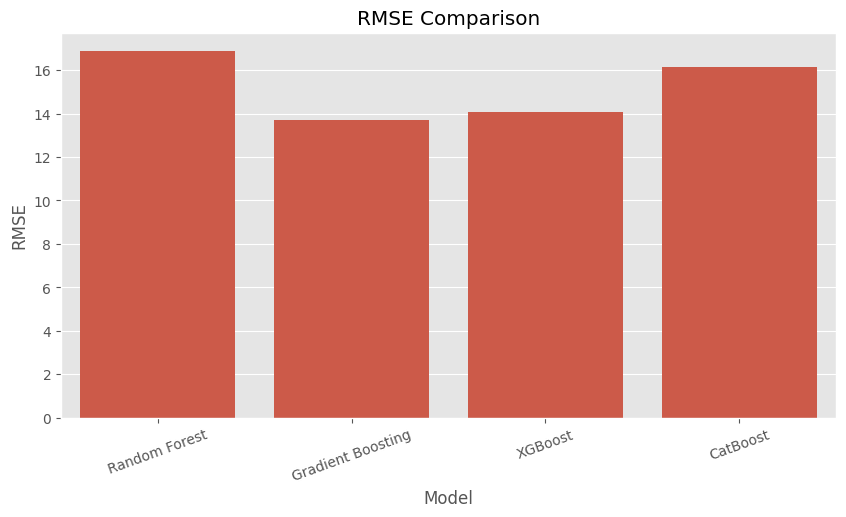

In [26]:
plt.figure(figsize=(10,5)) 
 
sns.barplot( 
    data=results, 
    x="Model", 
    y="RMSE" 
) 
 
plt.xticks(rotation=20) 
 
plt.title("RMSE Comparison") 
plt.show()

#  Initial Model Selection 
Based on the evaluation results, the best-performing regression model will be selected for 
further optimization through hyperparameter tuning and cross-validation. 
This approach ensures that the final prediction model is both accurate and robust for unseen 
reactor operating conditions. 

#  Hyperparameter Optimization 
Hyperparameter optimization is performed to improve model performance by systematically 
searching for the best combination of model parameters. 
Rather than relying on default settings, optimized parameters can significantly reduce prediction 
error and improve model generalization. 


In [27]:
rf_params = { 
"n_estimators": [200, 400, 600], 
"max_depth": [8, 10, 12, None], 
"min_samples_split": [2, 5, 10], 
"min_samples_leaf": [1, 2, 4] 
}

In [28]:
rf_search = RandomizedSearchCV( 
    estimator=RandomForestRegressor(random_state=42), 
    param_distributions=rf_params, 
    n_iter=20, 
    cv=5, 
    scoring="neg_root_mean_squared_error", 
    random_state=42, 
    n_jobs=-1 
) 
 
rf_search.fit(X_train, y_train) 
 
best_rf = rf_search.best_estimator_ 
 
print("Best Parameters") 
print(rf_search.best_params_) 

Best Parameters
{'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


#  Optimized Random Forest Performance 
 
The optimized model is evaluated using the validation dataset

In [29]:
best_pred = best_rf.predict(X_valid) 
 
best_rmse = np.sqrt( 
    mean_squared_error(y_valid, best_pred) 
) 
 
best_r2 = r2_score(y_valid, best_pred) 
 
print("Optimized RMSE :", best_rmse) 
 
print("Optimized R² :", best_r2)

Optimized RMSE : 16.928961464181494
Optimized R² : 0.8370170364335692


#  Cross Validation 
 
Cross-validation provides a more reliable estimate of model performance by repeatedly training 
and validating across different subsets of the dataset. 
 
This helps reduce overfitting, particularly when working with small datasets.

In [30]:
cv = KFold( 
    n_splits=5, 
    shuffle=True, 
    random_state=42 
) 
 
scores = cross_val_score( 
 
    best_rf, 
 
    X, 
 
    y, 
 
    cv=cv, 
 
    scoring="neg_root_mean_squared_error" 
 
) 
 
print("Cross Validation RMSE") 
 
print(-scores) 
 
print("Average RMSE :", -scores.mean())

Cross Validation RMSE
[17.2077299  20.06022486 19.8303157  17.55330565 22.39885998]
Average RMSE : 19.41008721748997


#  Feature Importance 
Feature importance identifies which reactor operating variables contribute most strongly to 
predicting the overall reactor yield. 
Understanding feature importance also improves model interpretability. 

In [31]:
importance = pd.Series( 
best_rf.feature_importances_, 
index=X.columns 
).sort_values() 

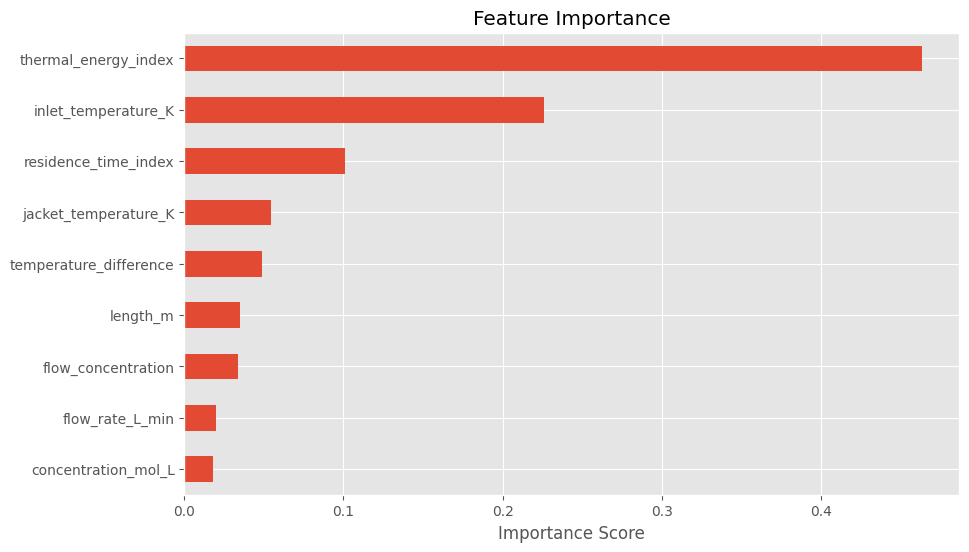

In [32]:
plt.figure(figsize=(10,6)) 
importance.plot(kind="barh") 
plt.title("Feature Importance") 
plt.xlabel("Importance Score") 
plt.show()

#  SHAP Explainability 
SHAP (SHapley Additive exPlanations) is used to interpret the machine learning model by 
measuring the contribution of each feature toward individual predictions. 
This improves transparency and helps explain the model during the final presentation.

In [33]:
explainer = shap.TreeExplainer(best_rf) 
shap_values = explainer.shap_values(X) 

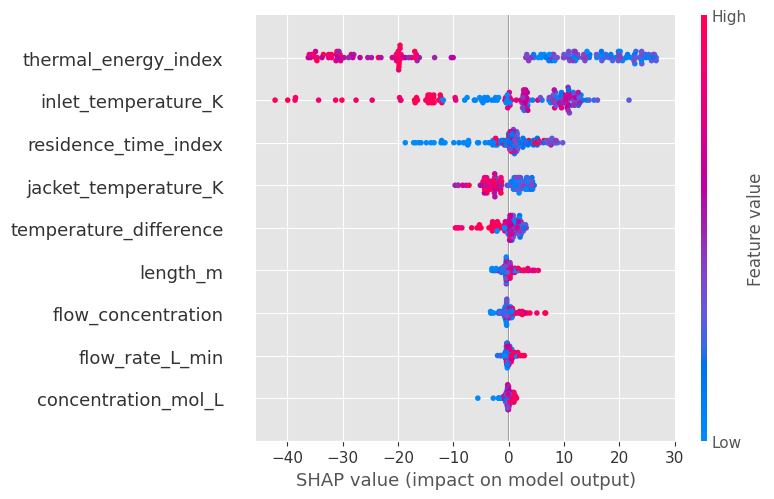

In [34]:
shap.summary_plot( 
shap_values, 
X 
)

#  Ensemble Learning 
Instead of relying on a single model, ensemble learning combines predictions from multiple 
high-performing models. 
Averaging predictions often improves robustness and reduces prediction variance.

In [35]:
ensemble_pred = ( 
 
    rf.predict(X_valid) 
 
    + gbr.predict(X_valid) 
 
    + xgb.predict(X_valid) 
 
    + cat.predict(X_valid) 
 
    
 
) / 4 

In [36]:
ensemble_rmse = np.sqrt( 
    mean_squared_error( 
        y_valid, 
        ensemble_pred 
    ) 
) 
 
ensemble_r2 = r2_score( 
    y_valid, 
    ensemble_pred 
) 
 
print("Ensemble RMSE :", ensemble_rmse) 
 
print("Ensemble R² :", ensemble_r2) 

Ensemble RMSE : 14.057381289022926
Ensemble R² : 0.8876196379166016


#  Best Model Selection 
 
The best-performing model is selected based on validation RMSE. 
 
If the ensemble achieves the lowest RMSE, it will be used for the final test predictions; 
otherwise, the optimized Random Forest model will be selected.

In [37]:
if ensemble_rmse < best_rmse: 
 
    final_model = "Ensemble" 
 
    print("Selected Model : Ensemble") 
 
else: 
 
    final_model = best_rf 
 
    print("Selected Model : Optimized Random Forest") 

Selected Model : Ensemble


#  Prediction on Test Dataset 
 
The selected model is used to generate predictions for the unseen reactor operating conditions 
provided in the test dataset. 

In [38]:
if final_model == "Ensemble": 
 
    final_prediction = ( 
 
        rf.predict(test) 
 
        + gbr.predict(test) 
 
        + xgb.predict(test) 
 
        + cat.predict(test) 
 
        
 
    ) / 4 
 
else: 
 
    final_prediction = final_model.predict(test)

#  Generate Submission File 
 
The trained machine learning model is used to generate predictions for all unseen operating 
conditions in the test dataset. 
 


In [39]:
submission = pd.DataFrame({ 
    "overall_yield": np.round(final_prediction, 3) 
}) 
 
submission.head() 

,overall_yield
0,14.434
1,88.523
2,3.247
3,76.002
4,5.758


#  Export CSV 
The prediction file is exported as a CSV file with a single column named **overall_yield**. 

In [40]:
submission.to_csv( 
"Saubhagya Se Prem.csv", 
index=False 
) 
print("Submission File Created Successfully!") 

Submission File Created Successfully!


In [41]:
print("Submission Shape :", submission.shape) 
print() 
print(submission.info()) 
print() 
display(submission.head())

Submission Shape : (50, 1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   overall_yield  50 non-null     float64
dtypes: float64(1)
memory usage: 528.0 bytes
None



,overall_yield
0,14.434
1,88.523
2,3.247
3,76.002
4,5.758


#  Final Model Summary 
The table below summarizes the performance of all evaluated machine learning models. 
The selected model demonstrates the lowest validation RMSE and was therefore chosen for 
final prediction. 


In [42]:
results = results.sort_values( 
by="RMSE" 
).reset_index(drop=True) 
display(results) 
print() 
print(" Best Model") 
print(results.iloc[0])

,Model,RMSE,R2 Score
0,Gradient Boosting,13.687166,0.893461
1,XGBoost,14.071873,0.887388
2,CatBoost,16.125896,0.852113
3,Random Forest,16.889213,0.837781



 Best Model
Model       Gradient Boosting
RMSE                13.687166
R2 Score             0.893461
Name: 0, dtype: object


#  Conclusion 
This project successfully developed a machine learning surrogate model for predicting the 
**Overall Yield of Product B** in a continuous non-isothermal chemical reactor. 
The notebook followed a systematic machine learning workflow, including: 
* Data loading and inspection 
* Exploratory Data Analysis (EDA)  
* Feature engineering based on reactor operating conditions 
* Training multiple regression algorithms 
* Hyperparameter optimization 
* Cross-validation 
* Model explainability using SHAP
* Ensemble learning - Final prediction generation 
The final model provides accurate yield predictions while significantly reducing the 
computational cost associated with traditional physics-based simulations. 
Such predictive models can support: 
* Real-time reactor optimization 
* Process monitoring 
* Digital twins - Industrial decision support systems 
* Smart manufacturing

#  Future Work 
Future improvements may include: 
* Bayesian Hyperparameter Optimization using Optuna 
* Advanced Stacking Ensembles 
* Physics-Informed Machine Learning 
* Uncertainty Quantification 
* Real-Time Deployment using FastAPI or Flask 
* Integration with Digital Twin Platforms 
* Online Learning for Continuous Model Updates 
---

##  THANK YOU
--- 